State before final Hadamard


<IPython.core.display.Latex object>

State after final Hadamard


<IPython.core.display.Latex object>

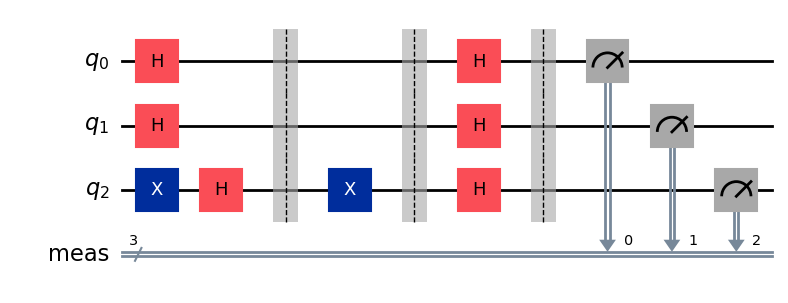

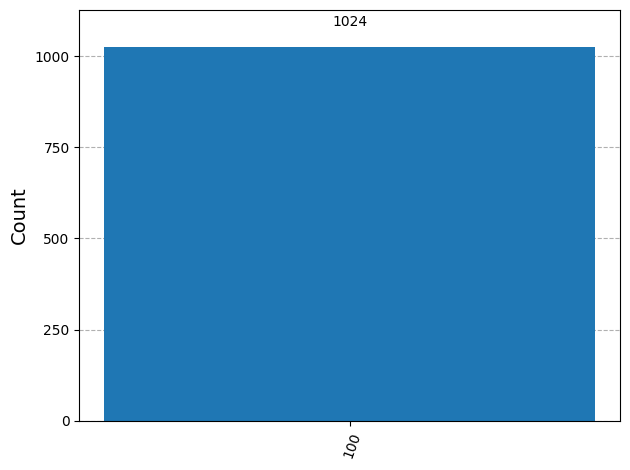

Result: Function is CONSTANT


In [8]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display
from qiskit.quantum_info import Statevector

def print_statevector(label, circuit):
    """Print statevector in Dirac notation."""
    state = Statevector.from_instruction(circuit)
    print(f"\n{label}:")
    print(state.draw(output='text'))

def build_oracle(circuit: QuantumCircuit, oracle_type: int, n_qubits: int, indices=None):
    """
    Constructs oracle for Deutsch-Jozsa algorithm.

    Parameters:
        circuit     : QuantumCircuit object
        oracle_type : 1:balanced function, 2:constant function
        n_qubits    : number of input qubits
        indices     : list of control qubit indices
    """
    target = n_qubits

    if oracle_type == 2:
        circuit.x(target)

    else:
        for i in indices:
            circuit.cx(i, target)


def get_user_input():
    n = int(input("Enter number of input qubits: "))
    choice = int(input(
        "Select oracle type:\n"
        "1 → balanced function\n"
        "2 → Constant function\n"
        "Choice: "
    ))
    return n, choice


def get_indices(choice):

    if choice == 1:
        k = int(input("Enter number of control qubits: "))
        indices = []
        for i in range(k):
            idx = int(input(f"Enter index of control qubit {i+1}: "))
            indices.append(idx)
        return indices

    return None


def main():
    n, choice = get_user_input()

    oracle = QuantumCircuit(n + 1)

    # Initialization
    oracle.x(n)
    oracle.h(range(n + 1))
    oracle.barrier()

    # Oracle construction
    indices = get_indices(choice)

    if choice == 2:
        const_val = int(input("Enter constant output (0 or 1): "))
        if const_val == 1:
            build_oracle(oracle, choice, n)
    else:
        build_oracle(oracle, choice, n, indices)

    oracle.barrier()

    # -------- STATE BEFORE FINAL HADAMARD --------
    print("State before final Hadamard")
    state1 = Statevector(oracle)

    display(state1.draw(output="latex")) 
    # Final Hadamards
    oracle.h(range(n + 1))

    # -------- STATE AFTER FINAL HADAMARD --------
    print("State after final Hadamard")
    state2 = Statevector(oracle)
    display(state2.draw(output="latex"))

    # Measurement
    oracle.measure_all()
    display(oracle.draw("mpl"))

    # Simulation
    simulator = AerSimulator()
    result = simulator.run(oracle, shots=1024).result()
    counts = result.get_counts()

    display(plot_histogram(counts))

    # Result interpretation
    output = list(counts.keys())[0][1:]

    if output == "0" * n:
        print("Result: Function is CONSTANT")
    else:
        print("Result: Function is BALANCED")

if __name__ == "__main__":
    main()